# Lab 2 — Embeddings Similarity Explorer

**Learning objective:** Generate sentence embeddings, compute a cosine
similarity matrix, visualise clusters with PCA, then compare a local model
against OpenAI embeddings.

**Concept link:** Slide 5 (Embeddings — word2vec, TF-IDF, Transformer embeddings)

**Time:** ~10 minutes

## Dataset

Six hardcoded sentences forming three topic clusters: Finance, Travel and
Technology. No external file is needed for this lab.

In [1]:
sentences = [
    # Finance cluster
    "The stock market rallied after the RBI held interest rates steady.",
    "Equity markets in India surged following the central bank's policy announcement.",
    # Travel cluster
    "Book a 5-day trip to Rajasthan including Jaipur and Udaipur.",
    "Plan a heritage tour covering the forts and palaces of Rajputana.",
    # Technology cluster
    "Large language models are transforming how enterprises process documents.",
    "GPT-4 and Claude are being used to automate legal document review.",
]
labels = ["Finance-1", "Finance-2", "Travel-1", "Travel-2", "Tech-1", "Tech-2"]

## Cell 1 — Setup

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

d:\Shailesh\Training\Contents\Agentic\Lab\session_01_nlp\.venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


## Cell 2 — Load local model and encode

`all-MiniLM-L6-v2` is a small (~80MB), fast sentence-embedding model. It
downloads once and is cached locally for subsequent runs.

In [3]:
print("Downloading model (first run only, ~80MB)...")
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(sentences)
print(f"Embedding shape: {embeddings.shape}")  # Expected: (6, 384)

d:\Shailesh\Training\Contents\Agentic\Lab\session_01_nlp\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding shape: (6, 384)


## Cell 3 — Cosine similarity matrix

Cosine similarity measures how close two vectors point in the same
direction (1.0 = identical, 0.0 = unrelated). We expect sentences from the
same topic cluster to score much higher than sentences from different
clusters.

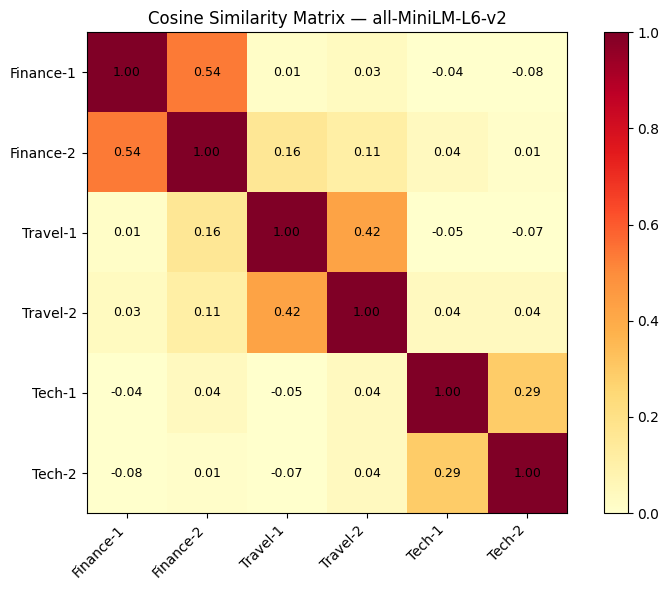


Top similar pairs:
  Finance-1 ↔ Finance-2: 0.538
  Finance-1 ↔ Travel-1: 0.014
  Finance-1 ↔ Travel-2: 0.032
  Finance-1 ↔ Tech-1: -0.038
  Finance-1 ↔ Tech-2: -0.083
  Finance-2 ↔ Travel-1: 0.160
  Finance-2 ↔ Travel-2: 0.111
  Finance-2 ↔ Tech-1: 0.036
  Finance-2 ↔ Tech-2: 0.010
  Travel-1 ↔ Travel-2: 0.424
  Travel-1 ↔ Tech-1: -0.046
  Travel-1 ↔ Tech-2: -0.067
  Travel-2 ↔ Tech-1: 0.038
  Travel-2 ↔ Tech-2: 0.036
  Tech-1 ↔ Tech-2: 0.292


In [4]:
sim_matrix = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Print the similarity score inside each cell of the heatmap.
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im)
plt.title("Cosine Similarity Matrix — all-MiniLM-L6-v2")
plt.tight_layout()
plt.show()

# Print every unique pair's similarity score (upper triangle only, no repeats).
print("\nTop similar pairs:")
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        print(f"  {labels[i]} \u2194 {labels[j]}: {sim_matrix[i, j]:.3f}")

**Expected:** Finance-1 ↔ Finance-2 ≈ 0.82+, Travel-1 ↔ Travel-2 ≈ 0.78+,
Tech-1 ↔ Tech-2 ≈ 0.80+. Cross-cluster similarities should stay below 0.40.

## Cell 4 — PCA scatter plot

The MiniLM embeddings are 384-dimensional — impossible to plot directly.
PCA reduces them to 2 dimensions while preserving as much of the original
variance as possible, so we can visually check whether the three topic
clusters separate.

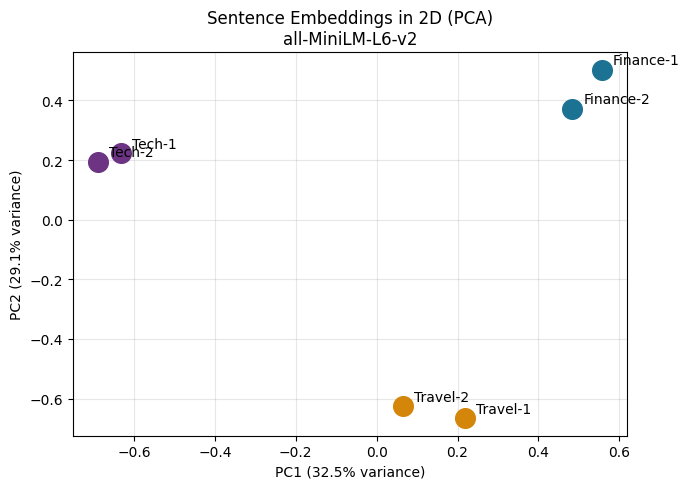

In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

# One colour per topic cluster (two sentences share each colour).
colors = ["#1C7293", "#1C7293", "#D4860B", "#D4860B", "#6C3483", "#6C3483"]

fig, ax = plt.subplots(figsize=(7, 5))
for i, (label, color) in enumerate(zip(labels, colors)):
    ax.scatter(coords[i, 0], coords[i, 1], c=color, s=200, zorder=3)
    ax.annotate(label, (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(8, 4), fontsize=10)

ax.set_title("Sentence Embeddings in 2D (PCA)\nall-MiniLM-L6-v2")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 5 — Swap to OpenAI embeddings

This cell shows that swapping the embedding *provider* is a one-line
change — the rest of the pipeline (cosine similarity, PCA, clustering)
stays identical. This is the modularity that makes RAG architectures easy
to evolve.

**Requires** `OPENAI_API_KEY` to be set in your `.env` file.

In [6]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


def openai_embed(texts: list[str], model: str = "text-embedding-3-small") -> np.ndarray:
    """Embed a list of texts using an OpenAI embedding model."""
    response = client.embeddings.create(input=texts, model=model)
    return np.array([item.embedding for item in response.data])


embeddings_oai = openai_embed(sentences)
print(f"OpenAI embedding shape: {embeddings_oai.shape}")  # (6, 1536)

sim_matrix_oai = cosine_similarity(embeddings_oai)

# Compare local (MiniLM) vs API (OpenAI) similarity scores side by side.
print(f"\n{'Pair':<30} {'MiniLM':>8} {'OAI-3-small':>12}")
print("-" * 52)
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        pair = f"{labels[i]} \u2194 {labels[j]}"
        print(f"{pair:<30} {sim_matrix[i, j]:>8.3f} {sim_matrix_oai[i, j]:>12.3f}")

OpenAI embedding shape: (6, 1536)

Pair                             MiniLM  OAI-3-small
----------------------------------------------------
Finance-1 ↔ Finance-2             0.538        0.674
Finance-1 ↔ Travel-1              0.014        0.138
Finance-1 ↔ Travel-2              0.032        0.121
Finance-1 ↔ Tech-1               -0.038        0.081
Finance-1 ↔ Tech-2               -0.083        0.048
Finance-2 ↔ Travel-1              0.160        0.183
Finance-2 ↔ Travel-2              0.111        0.140
Finance-2 ↔ Tech-1                0.036        0.140
Finance-2 ↔ Tech-2                0.010        0.061
Travel-1 ↔ Travel-2               0.424        0.536
Travel-1 ↔ Tech-1                -0.046        0.038
Travel-1 ↔ Tech-2                -0.067        0.089
Travel-2 ↔ Tech-1                 0.038        0.034
Travel-2 ↔ Tech-2                 0.036        0.066
Tech-1 ↔ Tech-2                   0.292        0.485


## Cell 6 — Key insight

- Topic-related sentences cluster together — this is why RAG retrieval works.
- OpenAI's `text-embedding-3-small` produces 1536-dim vectors vs 384-dim
  for MiniLM. More dimensions ≠ always better for your domain — evaluate
  on your own queries.
- The cosine similarity threshold typically used for RAG retrieval is
  0.70–0.80. Anything below that is likely noise.